<a href="https://colab.research.google.com/github/yannn-6243/PCD_Assignment01/blob/main/PCD_Assignment01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama : Hadyan Althaf Baswara<br>
NIM : 25/559377/PA/23527

Tugas 1 Pengolahan Citra Digital Downsampling

In [ ]:
import cv2
import numpy as np

def max_pooling(gambar, factor):
    tinggi, lebar, channel = gambar.shape
    tinggi_baru = tinggi // factor
    lebar_baru = lebar // factor
    hasil = np.zeros((tinggi_baru, lebar_baru, channel), dtype=np.uint8)

    for i in range(tinggi_baru):
        for j in range(lebar_baru):
            for k in range(channel):
                nilai_max = 0
                for a in range(factor):
                    for b in range(factor):
                        px = gambar[i*factor+a, j*factor+b, k]
                        if px > nilai_max:
                            nilai_max = px
                hasil[i, j, k] = nilai_max
    return hasil


def average_pooling(gambar, factor):
    tinggi, lebar, channel = gambar.shape
    tinggi_baru = tinggi // factor
    lebar_baru = lebar // factor
    hasil = np.zeros((tinggi_baru, lebar_baru, channel), dtype=np.uint8)

    for i in range(tinggi_baru):
        for j in range(lebar_baru):
            for k in range(channel):
                total = 0
                for a in range(factor):
                    for b in range(factor):
                        total += int(gambar[i*factor+a, j*factor+b, k])
                hasil[i, j, k] = int(total / (factor*factor))
    return hasil


def median_pooling(gambar, factor):
    tinggi, lebar, channel = gambar.shape
    tinggi_baru = tinggi // factor
    lebar_baru = lebar // factor
    hasil = np.zeros((tinggi_baru, lebar_baru, channel), dtype=np.uint8)

    for i in range(tinggi_baru):
        for j in range(lebar_baru):
            for k in range(channel):
                kumpulan = []
                for a in range(factor):
                    for b in range(factor):
                        kumpulan.append(gambar[i*factor+a, j*factor+b, k])
                kumpulan.sort()
                hasil[i, j, k] = kumpulan[len(kumpulan)//2]
    return hasil

In [ ]:
def nn_upsampling(gambar_kecil, skala):
    h_kecil, w_kecil, channel = gambar_kecil.shape
    out_h = h_kecil * skala
    out_w = w_kecil * skala
    hasil = np.zeros((out_h, out_w, channel), dtype=np.uint8)

    for i in range(out_h):
        for j in range(out_w):
            src_i = i // skala
            src_j = j // skala
            for k in range(channel):
                hasil[i, j, k] = gambar_kecil[src_i, src_j, k]
    return hasil


def bilinear_upsampling(gambar_kecil, skala):
    h_kecil, w_kecil, channel = gambar_kecil.shape
    out_h = h_kecil * skala
    out_w = w_kecil * skala
    hasil = np.zeros((out_h, out_w, channel), dtype=np.uint8)

    for i in range(out_h):
        for j in range(out_w):
            y = i / skala
            x = j / skala
            y0 = int(y)
            x0 = int(x)
            y1 = min(y0+1, h_kecil-1)
            x1 = min(x0+1, w_kecil-1)
            dy = y - y0
            dx = x - x0
            for k in range(channel):
                atas = int(gambar_kecil[y0, x0, k])*(1-dx) + int(gambar_kecil[y0, x1, k])*dx
                bawah = int(gambar_kecil[y1, x0, k])*(1-dx) + int(gambar_kecil[y1, x1, k])*dx
                hasil[i, j, k] = int(atas*(1-dy) + bawah*dy)
    return hasil


def kernel_kubik(x, a=-0.5):
    x = abs(x)
    if x <= 1:
        return (a+2)*(x**3) - (a+3)*(x**2) + 1
    elif x < 2:
        return a*(x**3) - 5*a*(x**2) + 8*a*x - 4*a
    else:
        return 0


def bicubic_upsampling(gambar_kecil, skala):
    h_kecil, w_kecil, channel = gambar_kecil.shape
    out_h = h_kecil * skala
    out_w = w_kecil * skala
    hasil = np.zeros((out_h, out_w, channel), dtype=np.uint8)

    for i in range(out_h):
        for j in range(out_w):
            y = i / skala
            x = j / skala
            y0 = int(y)
            x0 = int(x)
            dy = y - y0
            dx = x - x0
            for k in range(channel):
                total = 0
                for m in range(-1, 3):
                    for n in range(-1, 3):
                        yi = y0 + m
                        xi = x0 + n
                        if yi < 0:
                            yi = 0
                        if yi >= h_kecil:
                            yi = h_kecil - 1
                        if xi < 0:
                            xi = 0
                        if xi >= w_kecil:
                            xi = w_kecil - 1
                        bobot = kernel_kubik(m - dy) * kernel_kubik(n - dx)
                        total += int(gambar_kecil[yi, xi, k]) * bobot
                if total < 0:
                    total = 0
                if total > 255:
                    total = 255
                hasil[i, j, k] = int(total)
    return hasil

In [ ]:
daftar_foto = ['sawah.jpg', 'sunset.jpg', 'pionir.jpg']
factor = 4

semua_hasil = {}

for nama_file in daftar_foto:
    print('proses', nama_file)

    gambar = cv2.imread(nama_file)
    gambar = cv2.cvtColor(gambar, cv2.COLOR_BGR2RGB)
    gambar = cv2.resize(gambar, (400, 300))

    hasil_max = max_pooling(gambar, factor)
    hasil_avg = average_pooling(gambar, factor)
    hasil_median = median_pooling(gambar, factor)

    hasil_nn = nn_upsampling(gambar, factor)
    hasil_bilinear = bilinear_upsampling(gambar, factor)
    hasil_bicubic = bicubic_upsampling(gambar, factor)

    nama_dasar = nama_file.split('.')[0]

    cv2.imwrite(nama_dasar + '_max.jpg', cv2.cvtColor(hasil_max, cv2.COLOR_RGB2BGR))
    cv2.imwrite(nama_dasar + '_average.jpg', cv2.cvtColor(hasil_avg, cv2.COLOR_RGB2BGR))
    cv2.imwrite(nama_dasar + '_median.jpg', cv2.cvtColor(hasil_median, cv2.COLOR_RGB2BGR))
    cv2.imwrite(nama_dasar + '_nn.jpg', cv2.cvtColor(hasil_nn, cv2.COLOR_RGB2BGR))
    cv2.imwrite(nama_dasar + '_bilinear.jpg', cv2.cvtColor(hasil_bilinear, cv2.COLOR_RGB2BGR))
    cv2.imwrite(nama_dasar + '_bicubic.jpg', cv2.cvtColor(hasil_bicubic, cv2.COLOR_RGB2BGR))

    semua_hasil[nama_dasar] = {
        'original': gambar,
        'max': hasil_max,
        'average': hasil_avg,
        'median': hasil_median,
        'nn': hasil_nn,
        'bilinear': hasil_bilinear,
        'bicubic': hasil_bicubic
    }

    print('selesai', nama_file)

print('semua foto sudah diproses')

proses sawah.jpg
selesai sawah.jpg
proses sunset.jpg
selesai sunset.jpg
proses pionir.jpg
selesai pionir.jpg
semua foto sudah diproses


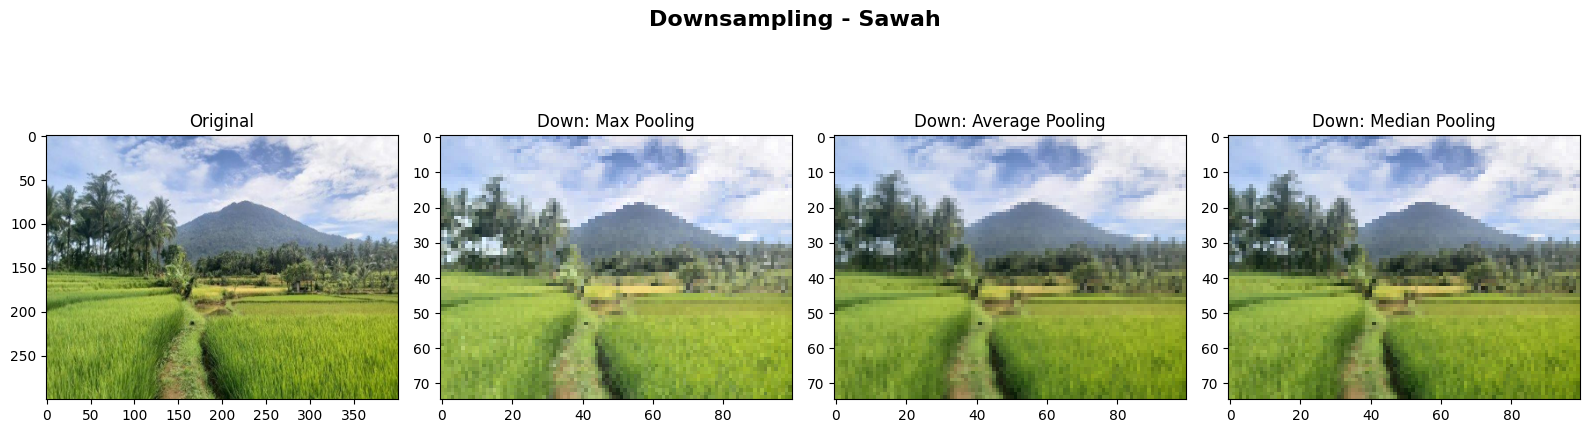

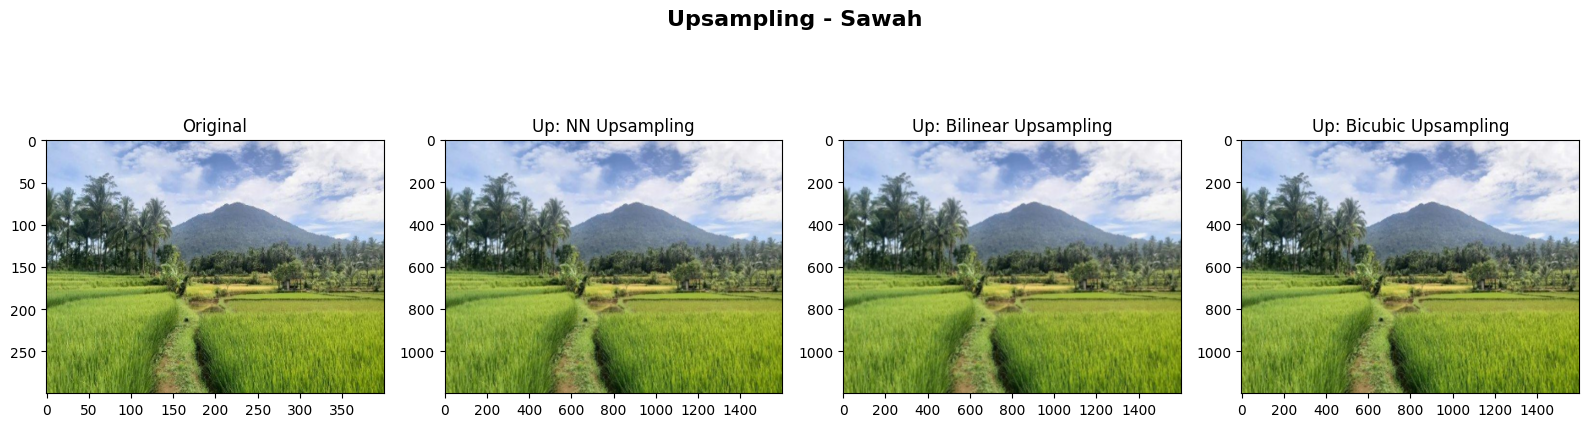

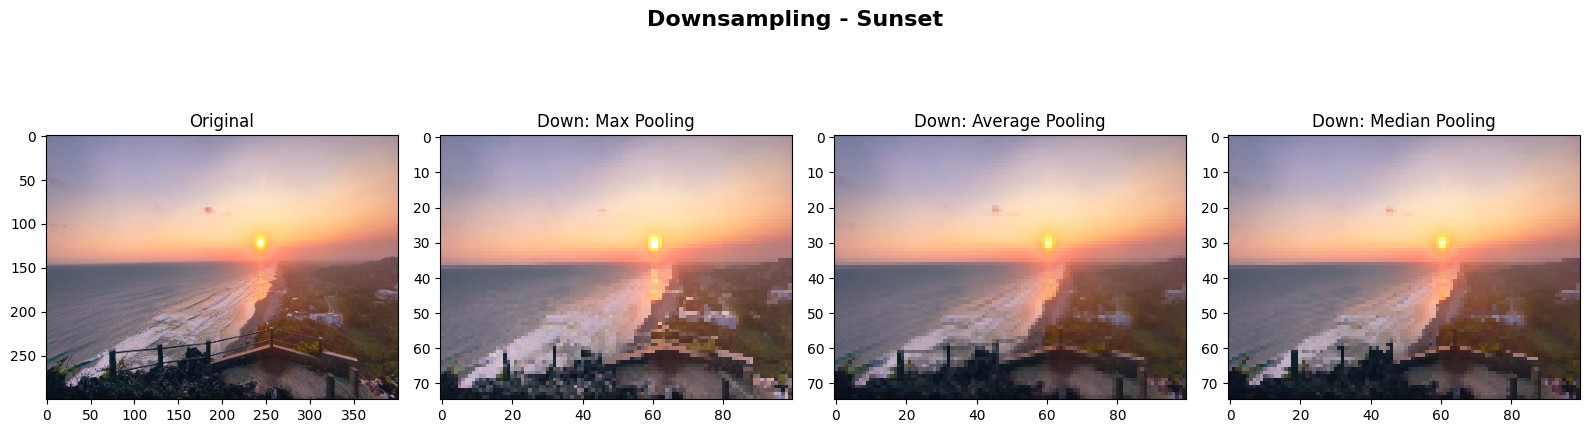

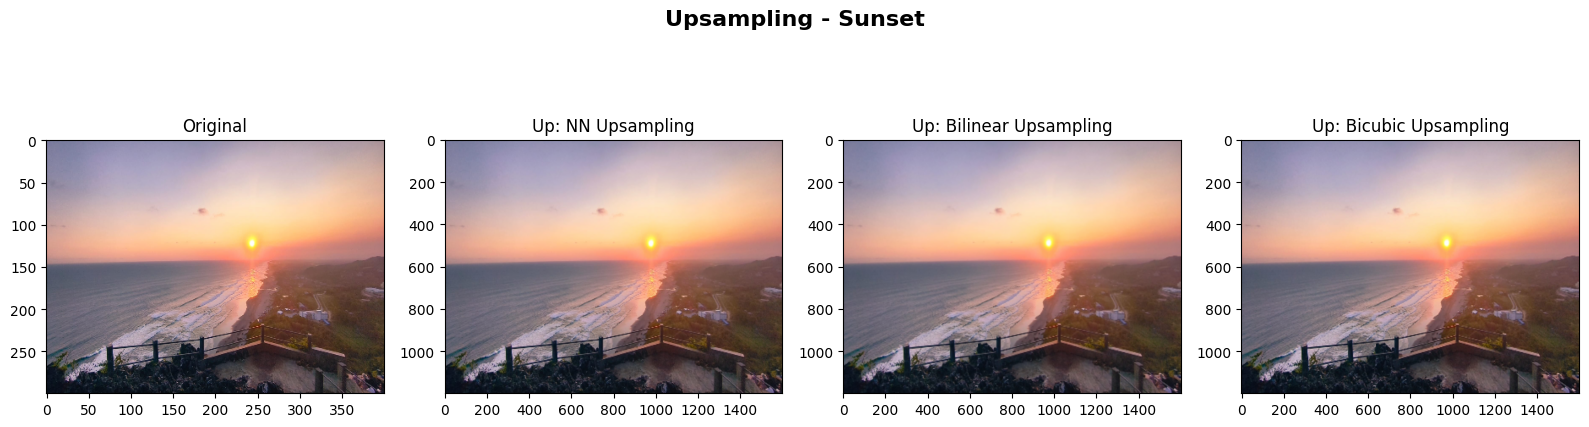

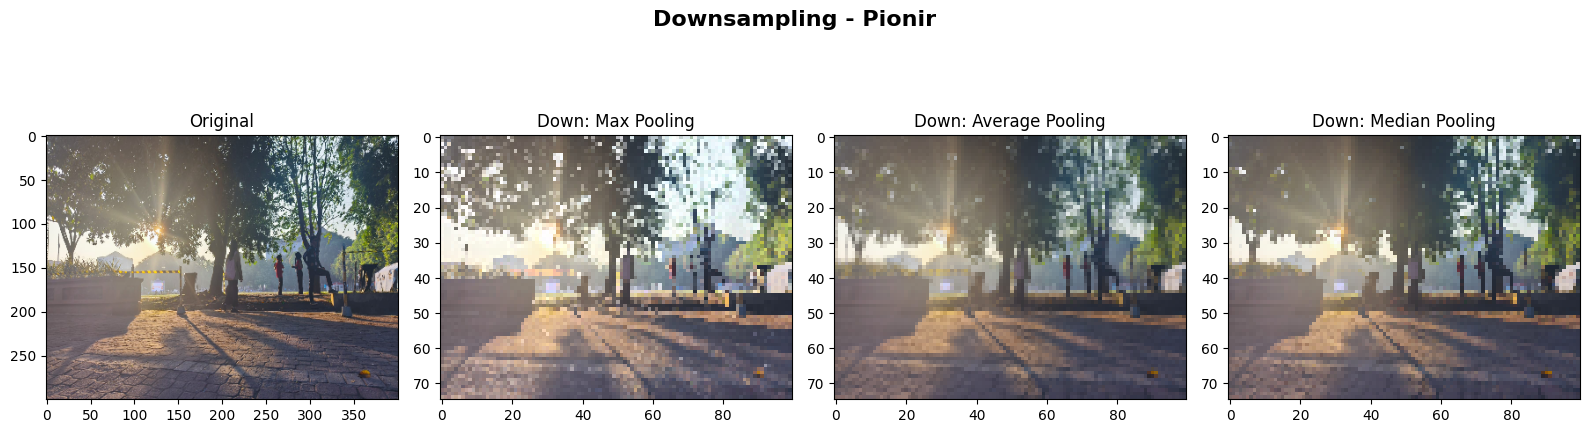

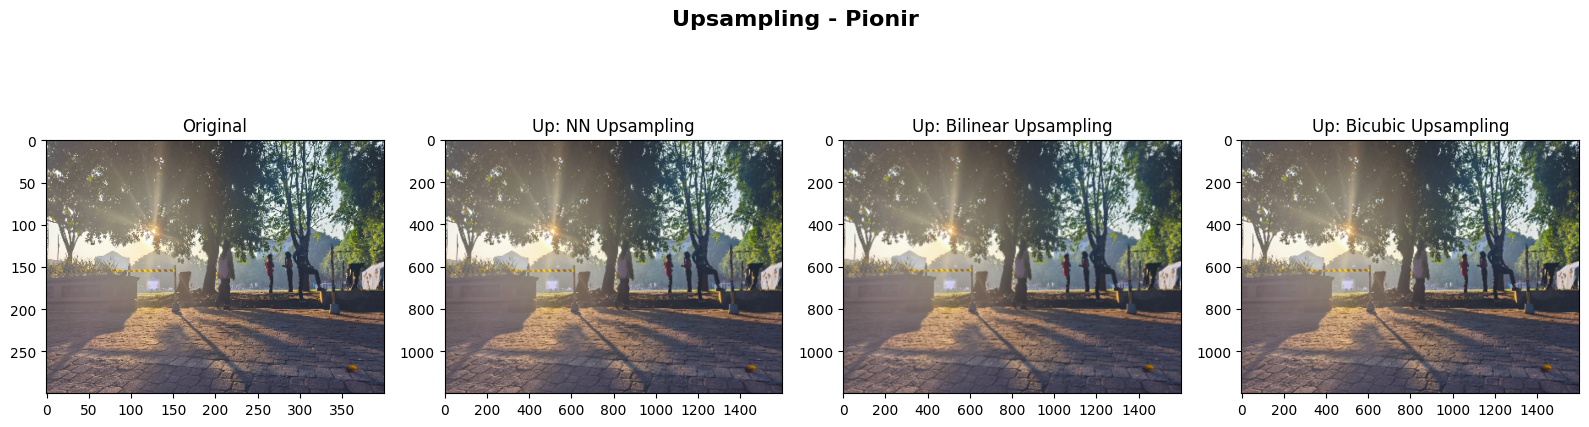

In [ ]:
import matplotlib.pyplot as plt

nama_tampilan = {
    'max': 'Max Pooling',
    'average': 'Average Pooling',
    'median': 'Median Pooling',
    'nn': 'NN Upsampling',
    'bilinear': 'Bilinear Upsampling',
    'bicubic': 'Bicubic Upsampling'
}

metode_down = ['max', 'average', 'median']
metode_up = ['nn', 'bilinear', 'bicubic']

for nama_dasar in semua_hasil:
    hasil = semua_hasil[nama_dasar]
    original = hasil['original']

    plt.figure(figsize=(16, 5))
    plt.suptitle(f"Downsampling - {nama_dasar.capitalize()}", fontsize=16, fontweight='bold')
    plt.subplot(1, 4, 1); plt.imshow(original); plt.title('Original')
    for idx, metode in enumerate(metode_down, start=2):
        plt.subplot(1, 4, idx)
        plt.imshow(hasil[metode])
        plt.title(f"Down: {nama_tampilan[metode]}")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(16, 5))
    plt.suptitle(f"Upsampling - {nama_dasar.capitalize()}", fontsize=16, fontweight='bold')
    plt.subplot(1, 4, 1); plt.imshow(original); plt.title('Original')
    for idx, metode in enumerate(metode_up, start=2):
        plt.subplot(1, 4, idx)
        plt.imshow(hasil[metode])
        plt.title(f"Up: {nama_tampilan[metode]}")
    plt.tight_layout()
    plt.show()